In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_rows', 500) #capability

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [36]:
df = pd.read_csv("/content/drive/MyDrive/csv_prueba1_mineria/nasa_exoplanet_intelligence.csv")

In [3]:
#df = pd.read_csv("/content/nasa_exoplanet_intelligence.csv") #creamos una variable que lee el archivo (un data frame en base al csv)

In [4]:
df.head() #muestra 5 primeras filas de la tabla

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,Kepler-1167 b,Kepler-1167,1,1,Transit,2016.0,Kepler,1.003934,1.710000,3.570,...,298.302660,47.693965,0,Super-Earth,False,False,False,Far(500-2kpc),K-type,Short(1-10d)
1,Kepler-1740 b,Kepler-1740,1,1,Transit,2021.0,Kepler,8.172400,3.323214,11.000,...,293.873663,38.922455,0,Mini-Neptune,False,False,True,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
2,Kepler-1581 b,Kepler-1581,1,1,Transit,2016.0,Kepler,6.283855,0.800000,0.437,...,287.371320,39.603623,0,Sub-Earth,False,False,False,Mid(100-500pc),F-type,Short(1-10d)
3,Kepler-644 b,Kepler-644,1,1,Transit,2016.0,Kepler,3.173917,3.150000,10.100,...,295.475702,43.493112,0,Mini-Neptune,False,False,False,Far(500-2kpc),F-type,Short(1-10d)
4,Kepler-1752 b,Kepler-1752,1,1,Transit,2021.0,Kepler,56.358501,4.540605,18.700,...,290.854140,51.222743,0,Neptune-like,False,False,True,Far(500-2kpc),G-type(Sun-like),Medium(10-100d)


In [5]:
df.tail() #muestra 5 ultimas filas de la tabla

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
6145,KMT-2024-BLG-1870L b,KMT-2024-BLG-1870L,1,1,Microlensing,2026.0,KMTNet,NaN,13.800,336.898111,...,272.465333,-26.882889,0,Gas Giant,False,False,True,Distant(2k+pc),Unknown,Unknown
6146,TOI-2267 b,TOI-2267 A,2,3,Transit,2025.0,Transiting Exoplanet Survey Satellite (TESS),2.28909,1.000,0.972000,...,65.061496,84.900824,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)
6147,TOI-813 b,TOI-813,1,1,Transit,2020.0,Transiting Exoplanet Survey Satellite (TESS),83.89110,6.710,36.400000,...,72.694010,-60.905461,0,Gas Giant,False,False,True,Mid(100-500pc),G-type(Sun-like),Medium(10-100d)
6148,LHS 1903 b,LHS 1903,1,4,Transit,2026.0,Transiting Exoplanet Survey Satellite (TESS),2.15551,1.382,3.280000,...,107.865826,48.327933,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)
6149,TOI-375 d,TOI-375,1,3,Radial Velocity,2026.0,Multiple Observatories,297.90000,13.600,445.595427,...,47.149903,-77.383327,0,Gas Giant,False,True,True,Mid(100-500pc),G-type(Sun-like),Long(100-365d)


In [6]:
df.columns #muestra columnas categoricas

Index(['planet_name', 'host_star', 'n_stars', 'n_planets', 'discovery_method',
       'disc_year', 'disc_facility', 'orbital_period_days',
       'planet_radius_earth', 'planet_mass_earth', 'equilibrium_temp_k',
       'orbital_eccentricity', 'semi_major_axis_au', 'star_temp_k',
       'star_radius_sun', 'star_mass_sun', 'star_age_gyr',
       'star_surface_gravity', 'star_metallicity', 'dist_from_earth_pc',
       'star_vmag', 'ra', 'dec', 'controversial_flag', 'planet_type',
       'habitable_zone_flag', 'multi_planet_system', 'is_recent_discovery',
       'dist_category', 'star_type', 'orbital_period_cat'],
      dtype='object')

In [7]:
df.shape #muestra numero de filas y cantidad de columnas

(6150, 31)

In [8]:
df.info() #muestra tipos de atos nulos en el dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6150 entries, 0 to 6149
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   planet_name           6150 non-null   object 
 1   host_star             6150 non-null   object 
 2   n_stars               6150 non-null   int64  
 3   n_planets             6150 non-null   int64  
 4   discovery_method      6150 non-null   object 
 5   disc_year             6149 non-null   float64
 6   disc_facility         6150 non-null   object 
 7   orbital_period_days   5816 non-null   float64
 8   planet_radius_earth   6100 non-null   float64
 9   planet_mass_earth     6119 non-null   float64
 10  equilibrium_temp_k    4587 non-null   float64
 11  orbital_eccentricity  5212 non-null   float64
 12  semi_major_axis_au    5834 non-null   float64
 13  star_temp_k           5860 non-null   float64
 14  star_radius_sun       5836 non-null   float64
 15  star_mass_sun        

In [10]:
df['planet_name'].value_counts() #muestra info de columna categorica

,count
planet_name,
TOI-375 d,1
Kepler-1167 b,1
Kepler-1740 b,1
Kepler-1581 b,1
Kepler-644 b,1
...,...
K2-19 b,1
HD 168746 b,1
Kepler-1101 b,1


In [11]:
df['planet_name'].value_counts().count() #muestra cantidad de columnas en variable categorica

np.int64(6150)

In [12]:
df['planet_type'].value_counts()

,count
planet_type,
Mini-Neptune,2148
Gas Giant,1734
Super-Earth,1185
Neptune-like,479
Super-Jupiter,324
Sub-Earth,230
Unknown,50


In [13]:
df.isnull().sum() #mostrara la cantidad de nulos por columna

,0
planet_name,0
host_star,0
n_stars,0
n_planets,0
discovery_method,0
disc_year,1
disc_facility,0
orbital_period_days,334
planet_radius_earth,50
planet_mass_earth,31


In [14]:
df.describe().round() #estadistica en variables numericas #round borra los decimales

,n_stars,n_planets,disc_year,orbital_period_days,planet_radius_earth,planet_mass_earth,equilibrium_temp_k,orbital_eccentricity,semi_major_axis_au,star_temp_k,star_radius_sun,star_mass_sun,star_age_gyr,star_surface_gravity,star_metallicity,dist_from_earth_pc,star_vmag,ra,dec,controversial_flag
count,6150.0,6150.0,6149.0,5816.0,6100.0,6119.0,4587.0,5212.0,5834.0,5860.0,5836.0,6142.0,4839.0,5832.0,5600.0,6123.0,5855.0,6150.0,6150.0,6150.0
mean,1.0,2.0,2017.0,73594.0,6.0,407.0,913.0,0.0,16.0,5398.0,2.0,1.0,4.0,4.0,0.0,712.0,13.0,233.0,18.0,0.0
std,0.0,1.0,5.0,5273718.0,5.0,1143.0,464.0,0.0,349.0,1747.0,4.0,0.0,3.0,0.0,0.0,1212.0,3.0,92.0,37.0,0.0
min,1.0,1.0,1992.0,0.0,0.0,0.0,34.0,0.0,0.0,415.0,0.0,0.0,0.0,1.0,-1.0,1.0,1.0,0.0,-88.0,0.0
25%,1.0,1.0,2014.0,4.0,2.0,4.0,566.0,0.0,0.0,4905.0,1.0,1.0,2.0,4.0,-0.0,101.0,11.0,173.0,-11.0,0.0
50%,1.0,1.0,2016.0,11.0,3.0,9.0,818.0,0.0,0.0,5546.0,1.0,1.0,4.0,4.0,0.0,377.0,13.0,285.0,39.0,0.0
75%,1.0,2.0,2021.0,40.0,12.0,191.0,1164.0,0.0,0.0,5900.0,1.0,1.0,6.0,5.0,0.0,836.0,15.0,293.0,45.0,0.0
max,4.0,8.0,2026.0,402000000.0,87.0,9535.0,4050.0,1.0,19000.0,57000.0,88.0,11.0,16.0,8.0,1.0,8500.0,45.0,360.0,87.0,1.0


In [15]:
df_limpio = df.dropna() #borra nulos

In [16]:
df_limpio.to_csv("nuevo_csv_limpio.csv") #guardar una copia de csv limpio

In [19]:
# Agrupación de las columnas por tipo de datos
tipos = df.columns.to_series().groupby(df.dtypes).groups
# Conociendo la lista de columnas categóricas
ctext = tipos[np.dtype('object')]
len(ctext) # cantidad de columnas con datos categóricos.

8

In [20]:
# Conociendo la lista de columnas numéricas
columnas = df.columns
cnum = list(set(columnas) - set(ctext))
len(cnum)


23

In [21]:
# Completando valores faltantes datos cuantititavos
for columna in cnum:
  mean = df[columna].mean()
  df[columna] = df[columna].fillna(mean)

In [22]:
# Completando valores faltantes datos categóricos
for columna in ctext:
  mode = df[columna].mode()[0]
  df[columna] = df[columna].fillna(mode)


In [23]:
df.isnull().any().any()

np.False_

In [26]:
# Guardando el dataset preprocesado
df.to_csv("DataNASA_procesado.csv", index=False)

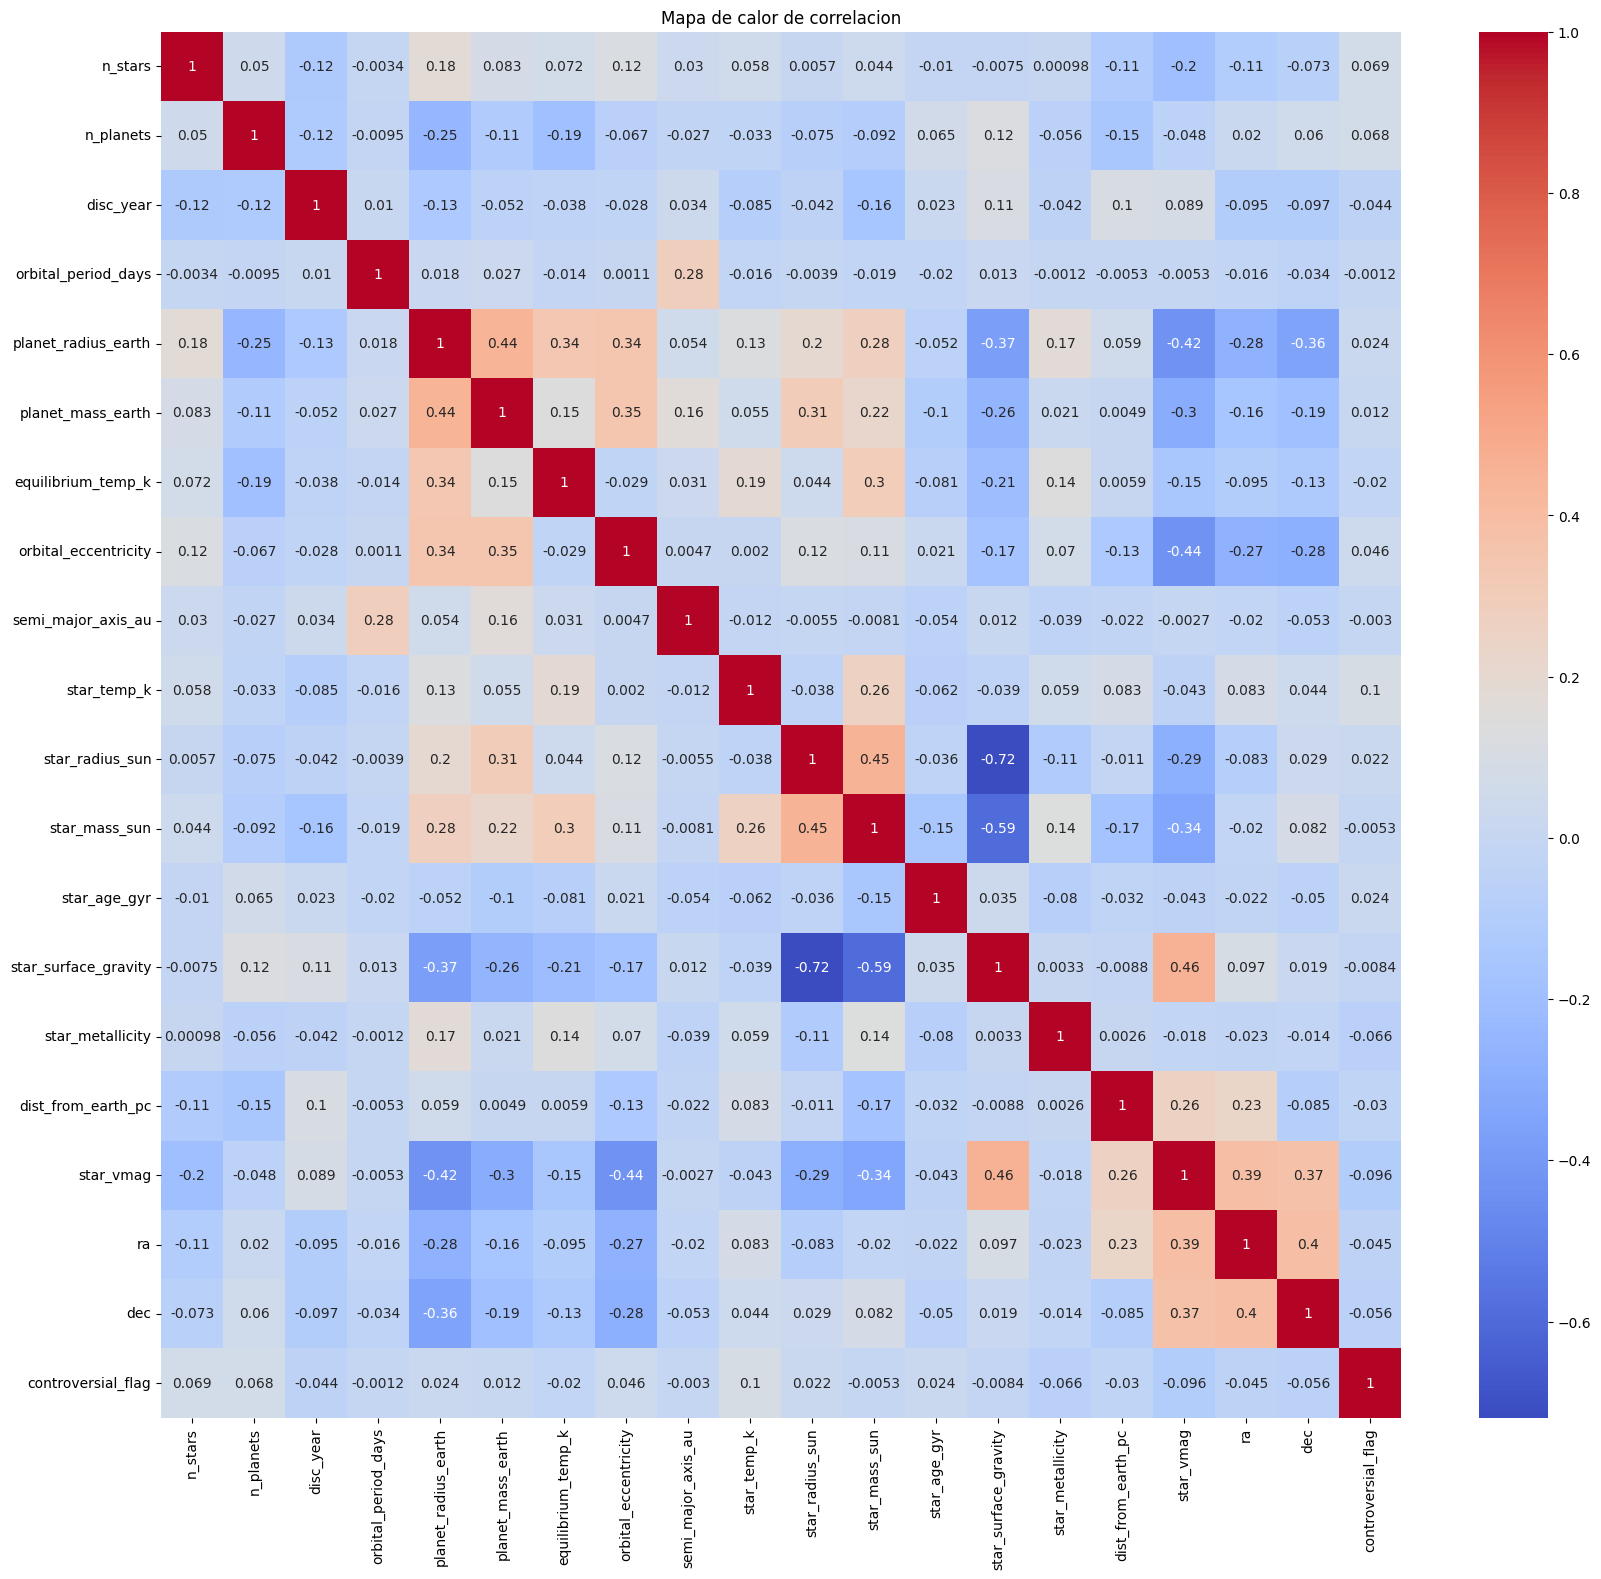

In [29]:
corr = df.select_dtypes(include='number').corr() #correlacion

plt.figure(figsize=(20,18))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Mapa de calor de correlacion")
plt.show()

In [32]:
import os

folder_path = '/content/drive/MyDrive/csv_prueba1_mineria/'

# Check if the directory exists
if os.path.exists(folder_path):
    print(f"Contents of '{folder_path}':")
    for item in os.listdir(folder_path):
        print(item)
else:
    print(f"The folder '{folder_path}' does not exist or is not accessible. Please ensure it is in your 'My Drive' and correctly named.")

Contents of '/content/drive/MyDrive/csv_prueba1_mineria/':
nasa_exoplanet_intelligence.csv
